In [1]:

!pip install kagglehub pandas numpy scikit-learn nltk textblob transformers torch gradio matplotlib seaborn wordcloud lime joblib -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:

# Import Libraries

import kagglehub
import pandas as pd
import numpy as np
import re
import string
import warnings
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob

# ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# Summarization
from transformers import pipeline as hf_pipeline

# Visualization
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:

# Download dataset from Kaggle
path = kagglehub.dataset_download("mucahiddemircan/real-and-fake-news-dataset")
print("Path to dataset files:", path)

# List files in the dataset directory
for root, dirs, files in os.walk(path):
    for file in files:
        filepath = os.path.join(root, file)
        print(f"Found file: {filepath}")

# Load the datasets
# The dataset typically contains True.csv and Fake.csv
true_path = None
fake_path = None

for root, dirs, files in os.walk(path):
    for file in files:
        filepath = os.path.join(root, file)
        if 'true' in file.lower() or 'real' in file.lower():
            true_path = filepath
        elif 'fake' in file.lower():
            fake_path = filepath

# Try loading based on found files
if true_path and fake_path:
    df_true = pd.read_csv(true_path)
    df_fake = pd.read_csv(fake_path)

    # Add labels
    df_true['label'] = 1  # 1 = Real
    df_fake['label'] = 0  # 0 = Fake

    # Combine datasets
    df = pd.concat([df_true, df_fake], ignore_index=True)
    print(f"\nLoaded True news: {len(df_true)} articles")
    print(f"Loaded Fake news: {len(df_fake)} articles")
else:
    # If structure is different, try loading single CSV
    csv_files = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))

    if csv_files:
        df = pd.read_csv(csv_files[0])
        print(f"Loaded dataset from: {csv_files[0]}")
    else:
        raise FileNotFoundError("No CSV files found in the dataset directory")

print(f"\nTotal dataset size: {len(df)} articles")
print(f"\nDataset columns: {df.columns.tolist()}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
df.head()

Using Colab cache for faster access to the 'real-and-fake-news-dataset' dataset.
Path to dataset files: /kaggle/input/real-and-fake-news-dataset
Found file: /kaggle/input/real-and-fake-news-dataset/news.csv
Loaded dataset from: /kaggle/input/real-and-fake-news-dataset/news.csv

Total dataset size: 45757 articles

Dataset columns: ['text', 'label']

Label distribution:
label
1    22900
0    22857
Name: count, dtype: int64


,text,label
0,Gere faults Trump for blurring meaning of 'ref...,1
1,German parties start to find common ground in ...,1
2,Senate Democratic leader says Attorney General...,1
3,"Tennis: Kyrgios fined $10,000 for Shanghai wal...",1
4,Trump Threw Mar-A-Lago Fundraiser For Woman A...,0


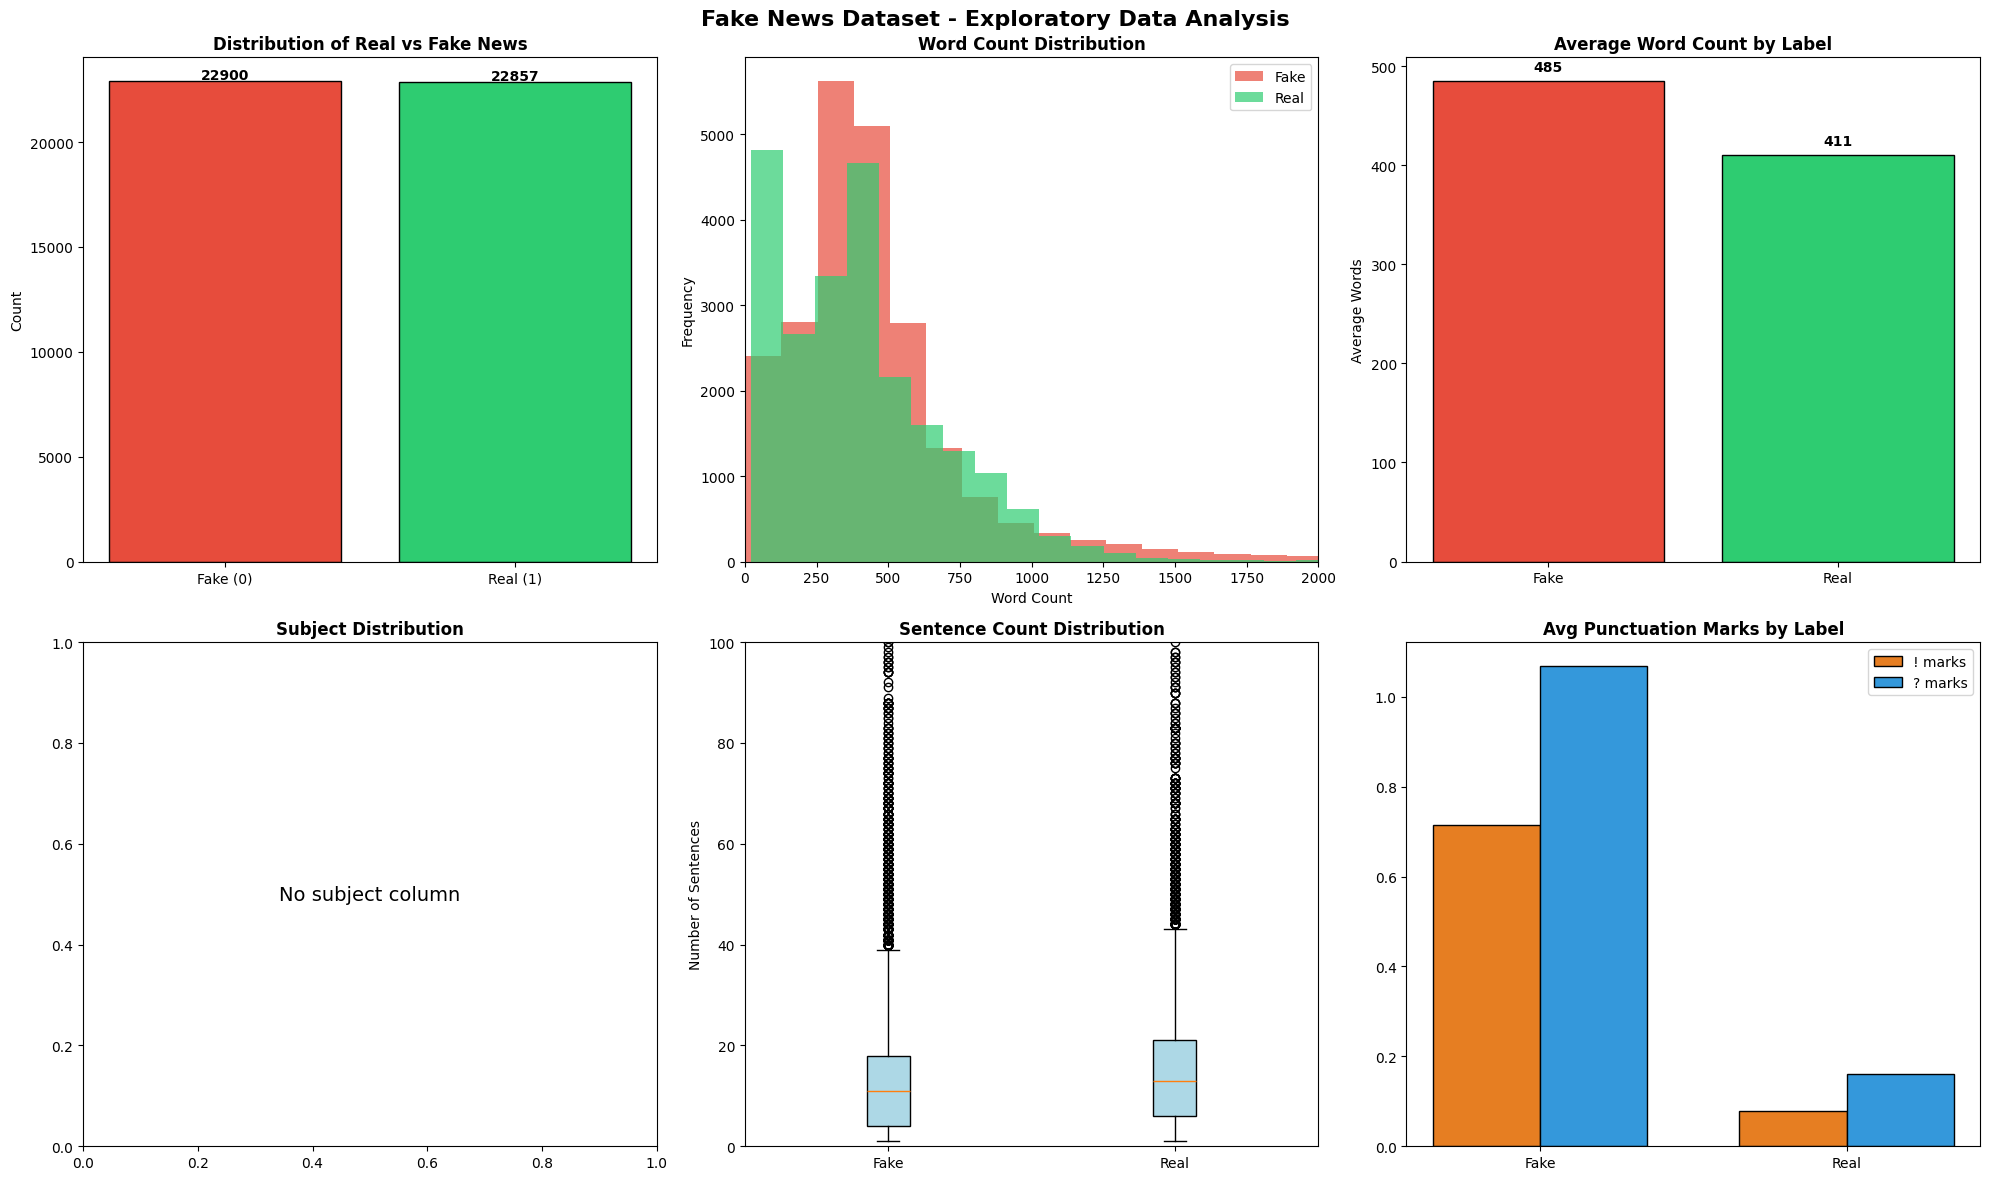

EDA plots saved!


In [4]:


fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Fake News Dataset - Exploratory Data Analysis', fontsize=16, fontweight='bold')

# 1. Label Distribution
label_counts = df['label'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0, 0].bar(['Fake (0)', 'Real (1)'], label_counts.values, color=colors, edgecolor='black')
axes[0, 0].set_title('Distribution of Real vs Fake News', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0, 0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# 2. Text Length Distribution
# Combine title and text if both exist
if 'text' in df.columns and 'title' in df.columns:
    df['full_text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
elif 'text' in df.columns:
    df['full_text'] = df['text'].fillna('')
elif 'title' in df.columns:
    df['full_text'] = df['title'].fillna('')

df['text_length'] = df['full_text'].apply(len)
df['word_count'] = df['full_text'].apply(lambda x: len(str(x).split()))

axes[0, 1].hist(df[df['label']==0]['word_count'], bins=50, alpha=0.7, label='Fake', color='#e74c3c')
axes[0, 1].hist(df[df['label']==1]['word_count'], bins=50, alpha=0.7, label='Real', color='#2ecc71')
axes[0, 1].set_title('Word Count Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 2000)

# 3. Average word count by label
avg_words = df.groupby('label')['word_count'].mean()
axes[0, 2].bar(['Fake', 'Real'], avg_words.values, color=colors, edgecolor='black')
axes[0, 2].set_title('Average Word Count by Label', fontweight='bold')
axes[0, 2].set_ylabel('Average Words')
for i, v in enumerate(avg_words.values):
    axes[0, 2].text(i, v + 10, f'{v:.0f}', ha='center', fontweight='bold')

# 4. Subject/Category distribution if available
if 'subject' in df.columns:
    subject_counts = df.groupby(['subject', 'label']).size().unstack(fill_value=0)
    subject_counts.plot(kind='bar', ax=axes[1, 0], color=colors, edgecolor='black')
    axes[1, 0].set_title('Articles by Subject & Label', fontweight='bold')
    axes[1, 0].set_xlabel('Subject')
    axes[1, 0].legend(['Fake', 'Real'])
    axes[1, 0].tick_params(axis='x', rotation=45)
else:
    axes[1, 0].text(0.5, 0.5, 'No subject column', ha='center', va='center', fontsize=14)
    axes[1, 0].set_title('Subject Distribution', fontweight='bold')

# 5. Sentence count distribution
df['sentence_count'] = df['full_text'].apply(lambda x: len(sent_tokenize(str(x))) if len(str(x)) > 0 else 0)
axes[1, 1].boxplot([df[df['label']==0]['sentence_count'].values,
                     df[df['label']==1]['sentence_count'].values],
                    labels=['Fake', 'Real'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
axes[1, 1].set_title('Sentence Count Distribution', fontweight='bold')
axes[1, 1].set_ylabel('Number of Sentences')
axes[1, 1].set_ylim(0, 100)

# 6. Exclamation and question marks
df['exclamation_count'] = df['full_text'].apply(lambda x: str(x).count('!'))
df['question_count'] = df['full_text'].apply(lambda x: str(x).count('?'))
avg_exc = df.groupby('label')['exclamation_count'].mean()
avg_q = df.groupby('label')['question_count'].mean()
x_pos = np.arange(2)
width = 0.35
axes[1, 2].bar(x_pos - width/2, avg_exc.values, width, label='! marks', color='#e67e22', edgecolor='black')
axes[1, 2].bar(x_pos + width/2, avg_q.values, width, label='? marks', color='#3498db', edgecolor='black')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(['Fake', 'Real'])
axes[1, 2].set_title('Avg Punctuation Marks by Label', fontweight='bold')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

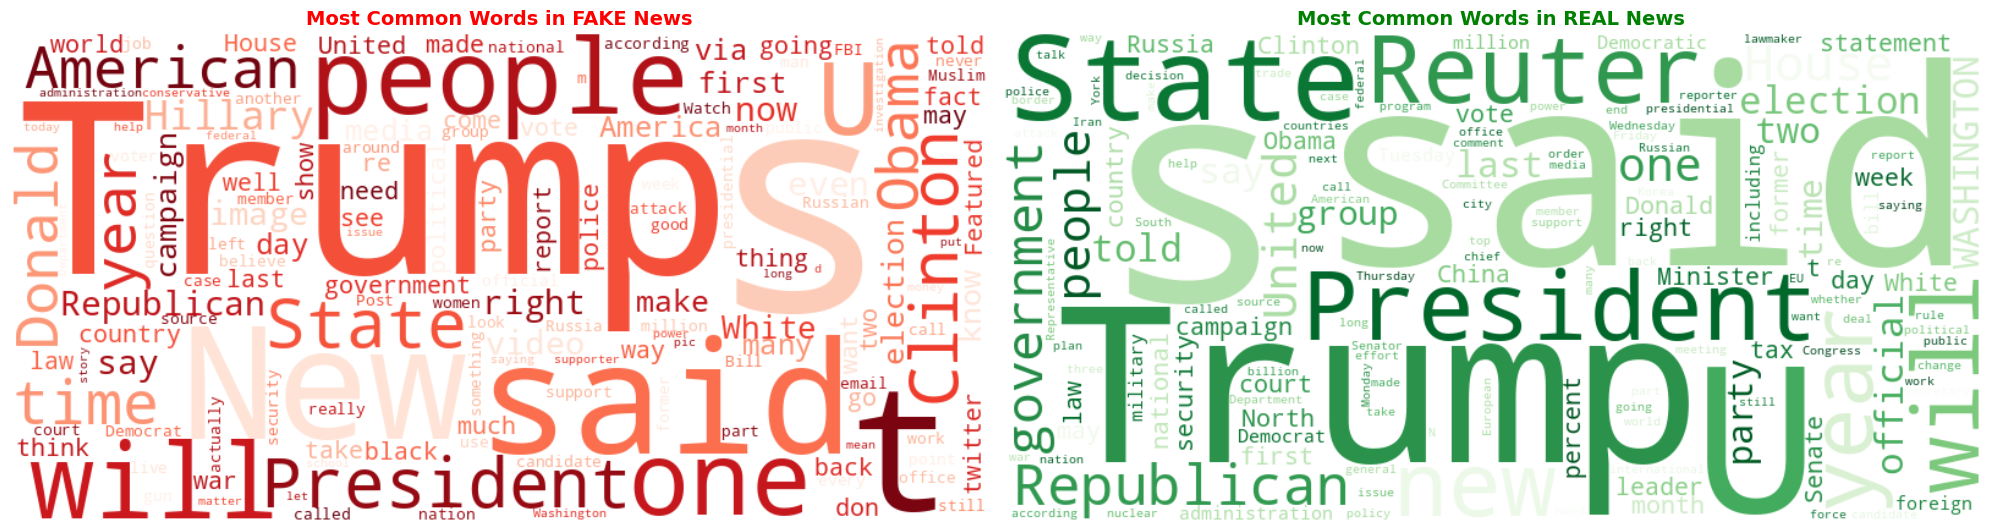

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Fake news word cloud
fake_text = ' '.join(df[df['label'] == 0]['full_text'].astype(str).tolist())
wc_fake = WordCloud(width=800, height=400, background_color='white',
                     colormap='Reds', max_words=150, collocations=False).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title('Most Common Words in FAKE News', fontsize=14, fontweight='bold', color='red')
axes[0].axis('off')

# Real news word cloud
real_text = ' '.join(df[df['label'] == 1]['full_text'].astype(str).tolist())
wc_real = WordCloud(width=800, height=400, background_color='white',
                     colormap='Greens', max_words=150, collocations=False).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title('Most Common Words in REAL News', fontsize=14, fontweight='bold', color='green')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:

class TextPreprocessor:
    """Comprehensive text preprocessor for fake news detection."""

    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
        # Sensationalist/clickbait words commonly found in fake news
        self.sensational_words = {
            'shocking', 'unbelievable', 'breaking', 'urgent', 'exclusive',
            'bombshell', 'stunning', 'incredible', 'horrifying', 'terrifying',
            'amazing', 'miracle', 'secret', 'conspiracy', 'exposed', 'revealed',
            'banned', 'censored', 'they dont want you to know', 'wake up',
            'share before deleted', 'must see', 'jaw dropping', 'mind blowing',
            'you wont believe', 'outrageous', 'insane', 'epic', 'destroyed',
            'obliterated', 'annihilated', 'slammed', 'blasted', 'torched'
        }

    def clean_text(self, text):
        """Basic text cleaning."""
        if pd.isna(text):
            return ""
        text = str(text)
        # Remove URLs
        text = re.sub(r'http\S+|www\.\S+', '', text)
        # Remove HTML tags
        text = re.sub(r'<.*?>', '', text)
        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)
        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def preprocess_for_tfidf(self, text):
        """Preprocess text for TF-IDF vectorization."""
        text = self.clean_text(text)
        text = text.lower()
        # Remove punctuation but keep some for feature extraction
        text = re.sub(r'[^\w\s]', ' ', text)
        # Tokenize
        tokens = word_tokenize(text)
        # Remove stopwords and lemmatize
        tokens = [self.lemmatizer.lemmatize(t) for t in tokens
                  if t not in self.stop_words and len(t) > 2 and not t.isdigit()]
        return ' '.join(tokens)

    def extract_linguistic_features(self, text):
        """Extract linguistic and stylistic features from text."""
        text = self.clean_text(text)
        features = {}

        if len(text) == 0:
            return {k: 0 for k in [
                'char_count', 'word_count', 'sentence_count', 'avg_word_length',
                'avg_sentence_length', 'vocabulary_richness', 'uppercase_ratio',
                'exclamation_count', 'question_count', 'ellipsis_count',
                'capital_word_count', 'sensational_word_count', 'sentiment_polarity',
                'sentiment_subjectivity', 'digit_ratio', 'punctuation_ratio',
                'quote_count', 'paragraph_count', 'long_word_ratio',
                'stopword_ratio', 'type_token_ratio'
            ]}

        words = text.split()
        sentences = sent_tokenize(text)

        # Basic counts
        features['char_count'] = len(text)
        features['word_count'] = len(words)
        features['sentence_count'] = len(sentences)
        features['avg_word_length'] = np.mean([len(w) for w in words]) if words else 0
        features['avg_sentence_length'] = len(words) / len(sentences) if sentences else 0

        # Vocabulary richness
        unique_words = set([w.lower() for w in words])
        features['vocabulary_richness'] = len(unique_words) / len(words) if words else 0

        # Stylistic features
        features['uppercase_ratio'] = sum(1 for c in text if c.isupper()) / len(text) if text else 0
        features['exclamation_count'] = text.count('!')
        features['question_count'] = text.count('?')
        features['ellipsis_count'] = text.count('...')
        features['capital_word_count'] = sum(1 for w in words if w.isupper() and len(w) > 1)

        # Sensationalist language
        text_lower = text.lower()
        features['sensational_word_count'] = sum(1 for sw in self.sensational_words if sw in text_lower)

        # Sentiment analysis
        blob = TextBlob(text[:5000])  # Limit text length for performance
        features['sentiment_polarity'] = blob.sentiment.polarity
        features['sentiment_subjectivity'] = blob.sentiment.subjectivity

        # Additional ratios
        features['digit_ratio'] = sum(1 for c in text if c.isdigit()) / len(text) if text else 0
        features['punctuation_ratio'] = sum(1 for c in text if c in string.punctuation) / len(text) if text else 0
        features['quote_count'] = text.count('"') + text.count("'")
        features['paragraph_count'] = text.count('\n') + 1

        # Long words ratio (words > 6 chars)
        features['long_word_ratio'] = sum(1 for w in words if len(w) > 6) / len(words) if words else 0

        # Stopword ratio
        stop_count = sum(1 for w in words if w.lower() in self.stop_words)
        features['stopword_ratio'] = stop_count / len(words) if words else 0

        # Type-token ratio (lexical diversity)
        features['type_token_ratio'] = len(set(words)) / len(words) if words else 0

        return features

# Initialize preprocessor
preprocessor = TextPreprocessor()

print("Preprocessing texts... This may take a few minutes.")

# Clean and preprocess texts
df['cleaned_text'] = df['full_text'].apply(preprocessor.preprocess_for_tfidf)

# Extract linguistic features (sample for speed if dataset is large)
print("Extracting linguistic features...")
linguistic_features = df['full_text'].apply(preprocessor.extract_linguistic_features)
linguistic_df = pd.DataFrame(linguistic_features.tolist())

print(f"\nExtracted {len(linguistic_df.columns)} linguistic features:")
print(linguistic_df.columns.tolist())
print(f"\nLinguistic features shape: {linguistic_df.shape}")
linguistic_df.describe()

Preprocessing texts... This may take a few minutes.
Extracting linguistic features...

Extracted 21 linguistic features:
['char_count', 'word_count', 'sentence_count', 'avg_word_length', 'avg_sentence_length', 'vocabulary_richness', 'uppercase_ratio', 'exclamation_count', 'question_count', 'ellipsis_count', 'capital_word_count', 'sensational_word_count', 'sentiment_polarity', 'sentiment_subjectivity', 'digit_ratio', 'punctuation_ratio', 'quote_count', 'paragraph_count', 'long_word_ratio', 'stopword_ratio', 'type_token_ratio']

Linguistic features shape: (45757, 21)


,char_count,word_count,sentence_count,avg_word_length,avg_sentence_length,vocabulary_richness,uppercase_ratio,exclamation_count,question_count,ellipsis_count,...,sensational_word_count,sentiment_polarity,sentiment_subjectivity,digit_ratio,punctuation_ratio,quote_count,paragraph_count,long_word_ratio,stopword_ratio,type_token_ratio
count,45757.000000,45757.000000,45757.000000,45757.000000,45757.000000,45757.000000,45757.000000,45757.000000,45757.000000,45757.000000,...,45757.000000,45757.000000,45757.000000,45757.000000,45757.000000,45757.000000,45757.000000,45757.000000,45757.000000,45757.000000
mean,2696.664008,447.229539,14.508206,5.060443,88.207152,0.600689,0.051266,0.389995,0.597504,0.087528,...,0.546037,0.057571,0.408167,0.006380,0.020501,0.940381,0.999891,0.281295,0.395973,0.625991
std,2361.610288,394.821096,13.646086,0.335678,295.853537,0.097466,0.040549,1.293139,1.675496,0.468858,...,0.817276,0.107763,0.124155,0.008010,0.009077,5.896778,0.010453,0.054581,0.055176,0.099646
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1362.000000,225.000000,5.000000,4.852060,24.000000,0.541004,0.033885,0.000000,0.000000,0.000000,...,0.000000,0.000439,0.341740,0.001473,0.017699,0.000000,1.000000,0.244898,0.365559,0.564576
50%,2306.000000,384.000000,12.000000,5.062096,28.333333,0.587571,0.041741,0.000000,0.000000,0.000000,...,0.000000,0.055916,0.410640,0.004356,0.020861,0.000000,1.000000,0.281124,0.396635,0.612360
75%,3300.000000,549.000000,19.000000,5.262673,35.500000,0.644351,0.054645,0.000000,0.000000,0.000000,...,1.000000,0.110046,0.479167,0.008550,0.024327,0.000000,1.000000,0.315789,0.432024,0.671429
max,32760.000000,6293.000000,369.000000,15.208333,6293.000000,1.000000,0.865546,37.000000,94.000000,53.000000,...,11.000000,1.000000,1.000000,0.307692,0.213918,316.000000,1.000000,0.700000,0.619048,1.000000


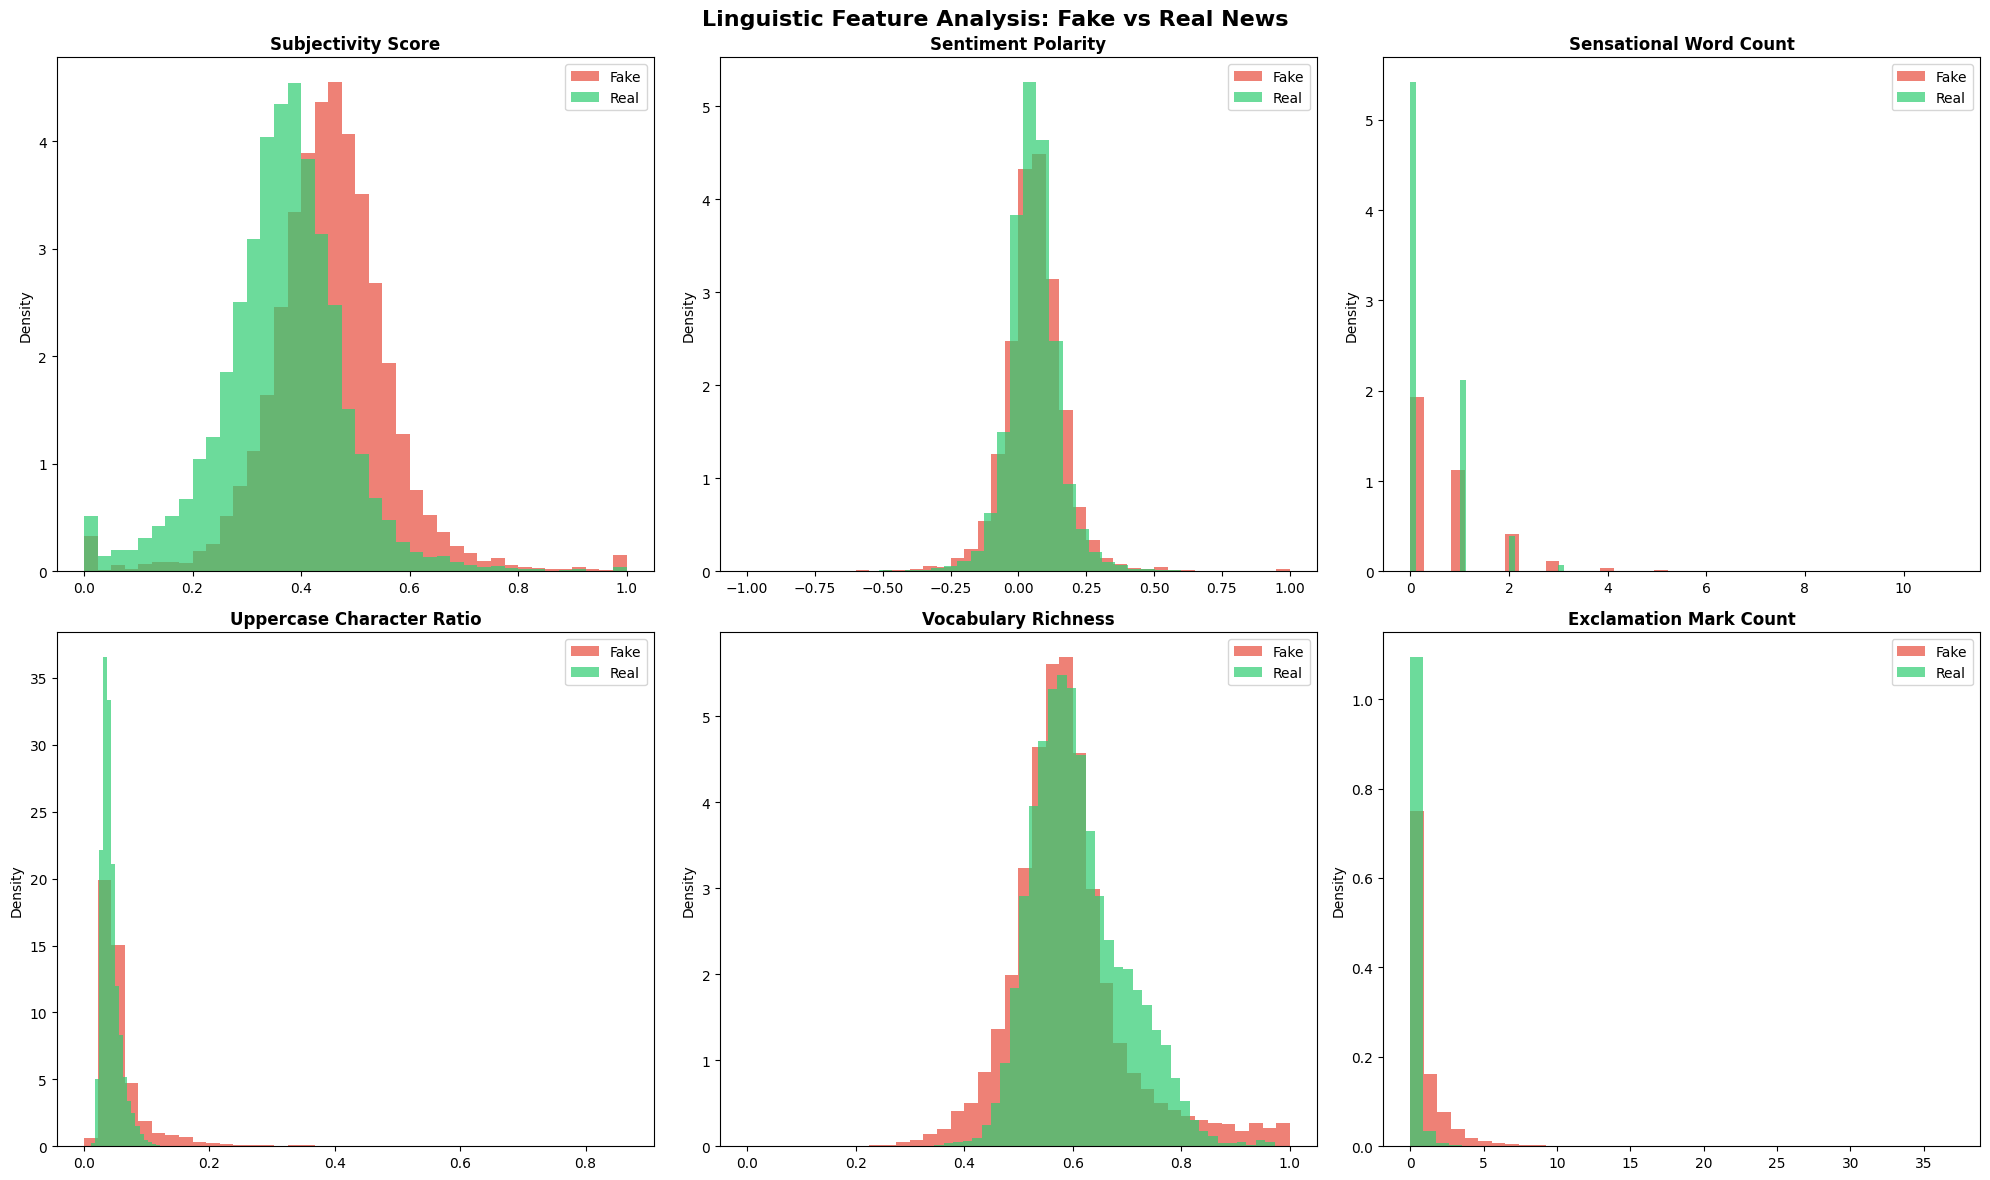

In [7]:

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Linguistic Feature Analysis: Fake vs Real News', fontsize=16, fontweight='bold')

features_to_plot = [
    ('sentiment_subjectivity', 'Subjectivity Score'),
    ('sentiment_polarity', 'Sentiment Polarity'),
    ('sensational_word_count', 'Sensational Word Count'),
    ('uppercase_ratio', 'Uppercase Character Ratio'),
    ('vocabulary_richness', 'Vocabulary Richness'),
    ('exclamation_count', 'Exclamation Mark Count')
]

for idx, (feat, title) in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    fake_vals = linguistic_df.loc[df['label'] == 0, feat]
    real_vals = linguistic_df.loc[df['label'] == 1, feat]

    ax.hist(fake_vals, bins=40, alpha=0.7, label='Fake', color='#e74c3c', density=True)
    ax.hist(real_vals, bins=40, alpha=0.7, label='Real', color='#2ecc71', density=True)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.set_ylabel('Density')

plt.tight_layout()
plt.savefig('linguistic_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:

print("=" * 60)
print("BUILDING CLASSIFICATION PIPELINE")
print("=" * 60)

# Split data
X_text = df['cleaned_text']
X_linguistic = linguistic_df.values
y = df['label']

X_text_train, X_text_test, X_ling_train, X_ling_test, y_train, y_test = train_test_split(
    X_text, X_linguistic, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_text_train)} samples")
print(f"Test set: {len(X_text_test)} samples")
print(f"Training label distribution:\n{y_train.value_counts()}")

# TF-IDF Vectorization
print("\nFitting TF-IDF Vectorizer...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True,
    dtype=np.float32
)

X_tfidf_train = tfidf_vectorizer.fit_transform(X_text_train)
X_tfidf_test = tfidf_vectorizer.transform(X_text_test)

print(f"TF-IDF matrix shape: {X_tfidf_train.shape}")

# Scale linguistic features
scaler = StandardScaler()
X_ling_train_scaled = scaler.fit_transform(X_ling_train)
X_ling_test_scaled = scaler.transform(X_ling_test)

# Combine TF-IDF + Linguistic features
X_combined_train = hstack([X_tfidf_train, csr_matrix(X_ling_train_scaled)])
X_combined_test = hstack([X_tfidf_test, csr_matrix(X_ling_test_scaled)])

print(f"Combined feature matrix shape: {X_combined_train.shape}")
print(f"  - TF-IDF features: {X_tfidf_train.shape[1]}")
print(f"  - Linguistic features: {X_ling_train_scaled.shape[1]}")

BUILDING CLASSIFICATION PIPELINE
Training set: 36605 samples
Test set: 9152 samples
Training label distribution:
label
1    18320
0    18285
Name: count, dtype: int64

Fitting TF-IDF Vectorizer...
TF-IDF matrix shape: (36605, 50000)
Combined feature matrix shape: (36605, 50021)
  - TF-IDF features: 50000
  - Linguistic features: 21


In [9]:

print("=" * 60)
print("TRAINING AND COMPARING CLASSIFIERS")
print("=" * 60)

classifiers = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs', random_state=42, n_jobs=-1
    ),
    'Multinomial NB (TF-IDF only)': MultinomialNB(alpha=0.1),
    'Linear SVM': LinearSVC(C=1.0, max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
    )
}

results = {}

for name, clf in classifiers.items():
    print(f"\nTraining {name}...")

    if 'NB' in name:
        # MultinomialNB needs non-negative features, use TF-IDF only
        clf.fit(X_tfidf_train, y_train)
        y_pred = clf.predict(X_tfidf_test)
        train_acc = clf.score(X_tfidf_train, y_train)
    else:
        clf.fit(X_combined_train, y_train)
        y_pred = clf.predict(X_combined_test)
        train_acc = clf.score(X_combined_train, y_train)

    test_acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'f1_score': f1,
        'predictions': y_pred
    }

    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print(f"  F1 Score:       {f1:.4f}")

# Results comparison
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
results_df = pd.DataFrame({
    name: {'Train Acc': r['train_acc'], 'Test Acc': r['test_acc'], 'F1 Score': r['f1_score']}
    for name, r in results.items()
}).T
print(results_df.round(4))

TRAINING AND COMPARING CLASSIFIERS

Training Logistic Regression...
  Train Accuracy: 0.9925
  Test Accuracy:  0.9908
  F1 Score:       0.9908

Training Multinomial NB (TF-IDF only)...
  Train Accuracy: 0.9585
  Test Accuracy:  0.9506
  F1 Score:       0.9506

Training Linear SVM...
  Train Accuracy: 0.9998
  Test Accuracy:  0.9956
  F1 Score:       0.9956

Training Random Forest...
  Train Accuracy: 1.0000
  Test Accuracy:  0.9854
  F1 Score:       0.9854

Training Gradient Boosting...
  Train Accuracy: 0.9995
  Test Accuracy:  0.9916
  F1 Score:       0.9916

MODEL COMPARISON SUMMARY
                              Train Acc  Test Acc  F1 Score
Logistic Regression              0.9925    0.9908    0.9908
Multinomial NB (TF-IDF only)     0.9585    0.9506    0.9506
Linear SVM                       0.9998    0.9956    0.9956
Random Forest                    1.0000    0.9854    0.9854
Gradient Boosting                0.9995    0.9916    0.9916


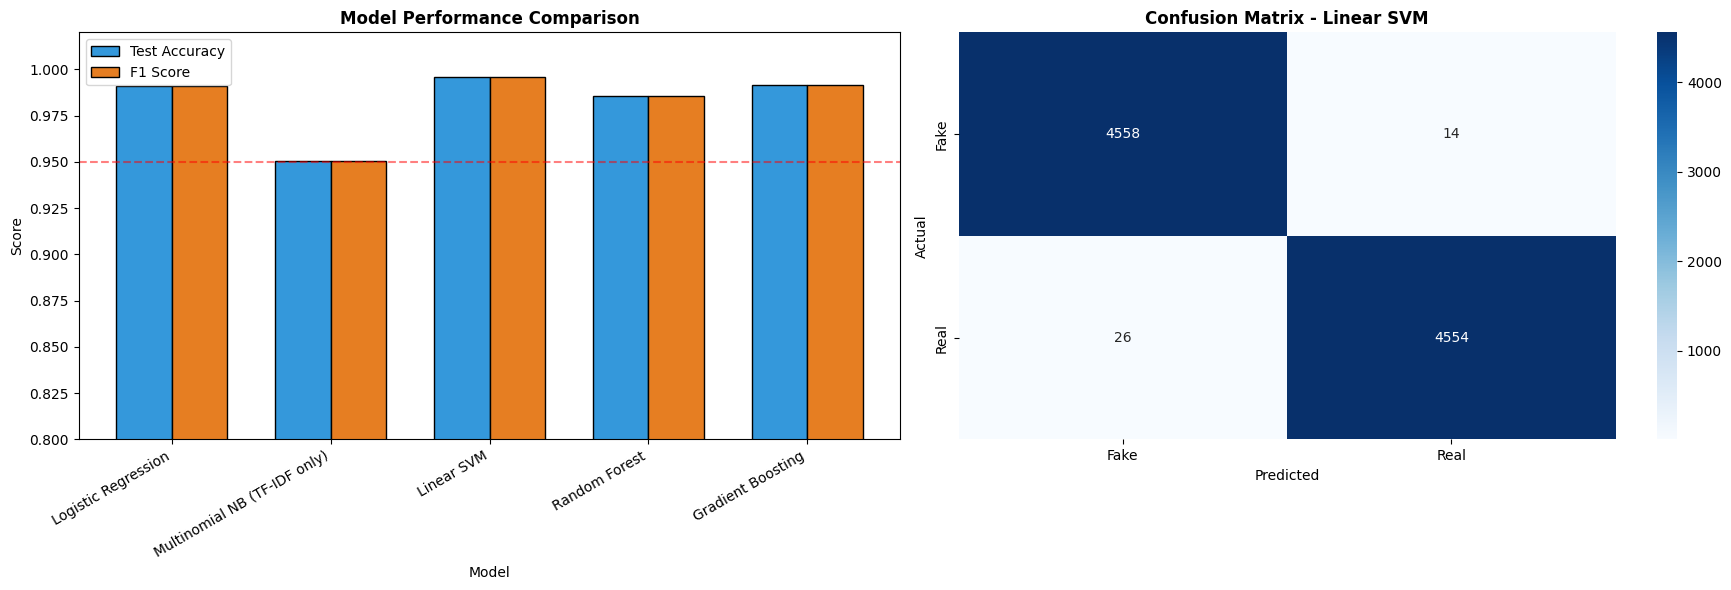


Best Model: Linear SVM

Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      1.00      1.00      4572
        Real       1.00      0.99      1.00      4580

    accuracy                           1.00      9152
   macro avg       1.00      1.00      1.00      9152
weighted avg       1.00      1.00      1.00      9152



In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Model comparison bar chart
model_names = list(results.keys())
test_accs = [results[m]['test_acc'] for m in model_names]
f1_scores = [results[m]['f1_score'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, test_accs, width, label='Test Accuracy', color='#3498db', edgecolor='black')
bars2 = axes[0].bar(x + width/2, f1_scores, width, label='F1 Score', color='#e67e22', edgecolor='black')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=30, ha='right')
axes[0].legend()
axes[0].set_ylim(0.8, 1.02)
axes[0].axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='95% threshold')

# Best model confusion matrix
best_model_name = max(results, key=lambda k: results[k]['f1_score'])
best_preds = results[best_model_name]['predictions']
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
axes[1].set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest Model: {best_model_name}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, best_preds, target_names=['Fake', 'Real']))

In [11]:

print("=" * 60)
print("TRAINING FINAL ENSEMBLE MODEL")
print("=" * 60)

# Use the best performing individual models in an ensemble
final_model = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42, n_jobs=-1)

# Train on combined features
final_model.fit(X_combined_train, y_train)

# Evaluate
y_pred_final = final_model.predict(X_combined_test)
y_prob_final = final_model.predict_proba(X_combined_test)

print(f"Final Model Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Final Model F1 Score: {f1_score(y_test, y_pred_final, average='weighted'):.4f}")
print(f"Final Model ROC-AUC: {roc_auc_score(y_test, y_prob_final[:, 1]):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Fake', 'Real']))

TRAINING FINAL ENSEMBLE MODEL
Final Model Test Accuracy: 0.9908
Final Model F1 Score: 0.9908
Final Model ROC-AUC: 0.9986

Classification Report:
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4572
        Real       0.99      0.99      0.99      4580

    accuracy                           0.99      9152
   macro avg       0.99      0.99      0.99      9152
weighted avg       0.99      0.99      0.99      9152



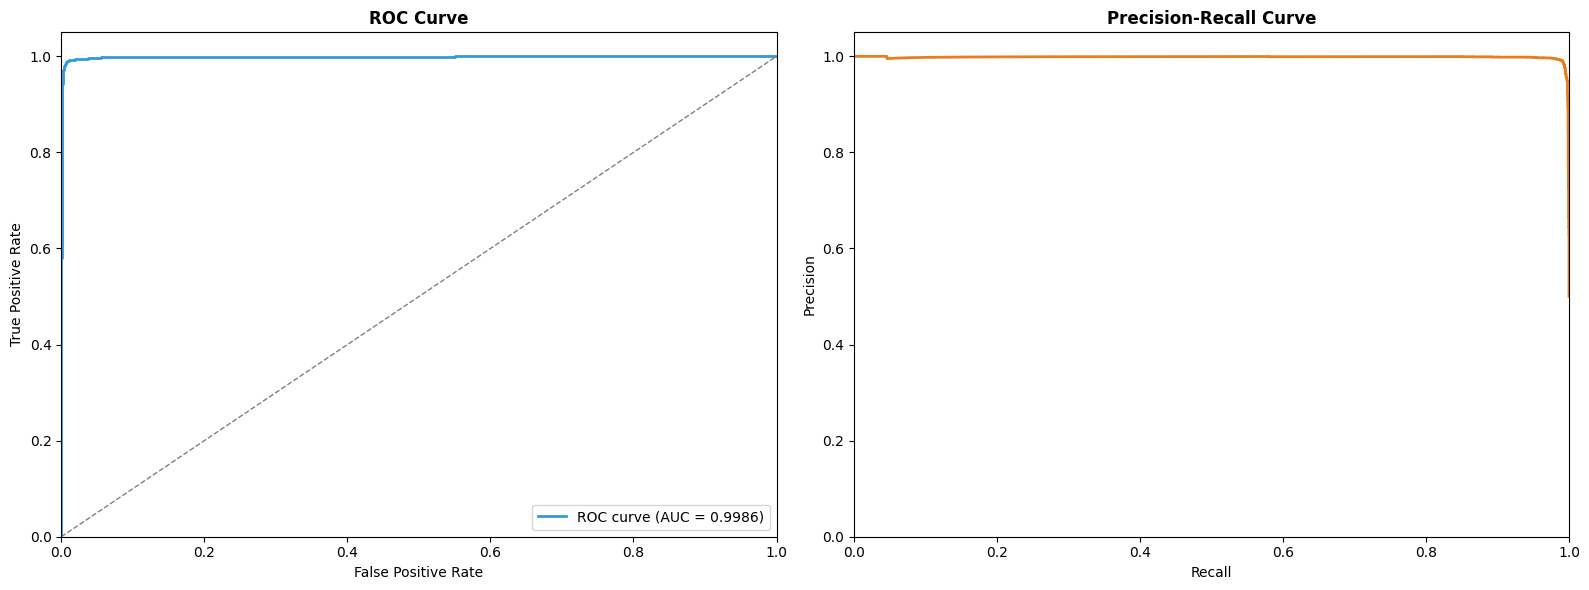

In [12]:
#
# ROC Curve & Precision-Recall Curve
#
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_final[:, 1])
roc_auc = roc_auc_score(y_test, y_prob_final[:, 1])
axes[0].plot(fpr, tpr, color='#3498db', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(loc='lower right')

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_final[:, 1])
axes[1].plot(recall, precision, color='#e67e22', lw=2)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Heuristic Credibility Scoring System
class CredibilityScorer:
    """Heuristic-based credibility scoring to complement ML predictions."""

    def __init__(self):
        self.preprocessor = TextPreprocessor()
        self.credible_indicators = [
            'according to', 'research shows', 'study finds', 'data suggests',
            'officials say', 'experts say', 'reported by', 'sources confirm',
            'evidence suggests', 'analysis shows', 'statistics indicate',
            'peer reviewed', 'published in', 'university of', 'institute of'
        ]
        self.non_credible_indicators = [
            'you wont believe', 'they dont want you to know', 'shocking truth',
            'share before', 'must see', 'breaking exclusive', 'conspiracy',
            'cover up', 'mainstream media lies', 'wake up sheeple',
            'big pharma', 'deep state', 'false flag', 'hoax',
            'click here', 'limited time', 'act now'
        ]

    def score_article(self, text):
        """Score an article's credibility on a 0-100 scale."""
        if not text or len(str(text).strip()) == 0:
            return 0, {}

        text = str(text)
        text_lower = text.lower()

        score = 50  # Start neutral
        breakdown = {}

        # 1. Source citation check (0-15 points)
        source_score = sum(2.5 for ind in self.credible_indicators if ind in text_lower)
        source_score = min(source_score, 15)
        score += source_score
        breakdown['source_citations'] = source_score

        # 2. Sensationalism penalty (-20 to 0)
        sensational_penalty = sum(-3 for ind in self.non_credible_indicators if ind in text_lower)
        sensational_penalty = max(sensational_penalty, -20)
        score += sensational_penalty
        breakdown['sensationalism_penalty'] = sensational_penalty

        # 3. Writing quality (0-10 points)
        words = text.split()
        if len(words) > 0:
            avg_word_len = np.mean([len(w) for w in words])
            if 4 <= avg_word_len <= 7:
                quality_score = 10
            elif 3 <= avg_word_len < 4 or 7 < avg_word_len <= 8:
                quality_score = 5
            else:
                quality_score = 0
        else:
            quality_score = 0
        score += quality_score
        breakdown['writing_quality'] = quality_score

        # 4. Excessive caps penalty (-10 to 0)
        if len(text) > 0:
            caps_ratio = sum(1 for c in text if c.isupper()) / len(text)
            if caps_ratio > 0.3:
                caps_penalty = -10
            elif caps_ratio > 0.15:
                caps_penalty = -5
            else:
                caps_penalty = 0
        else:
            caps_penalty = 0
        score += caps_penalty
        breakdown['caps_penalty'] = caps_penalty

        # 5. Excessive punctuation penalty (-10 to 0)
        excl_count = text.count('!')
        if excl_count > 5:
            punct_penalty = -10
        elif excl_count > 2:
            punct_penalty = -5
        else:
            punct_penalty = 0
        score += punct_penalty
        breakdown['punctuation_penalty'] = punct_penalty

        # 6. Article length bonus (0-10)
        if len(words) > 300:
            length_bonus = 10
        elif len(words) > 150:
            length_bonus = 5
        elif len(words) > 50:
            length_bonus = 2
        else:
            length_bonus = -5
        score += length_bonus
        breakdown['length_bonus'] = length_bonus

        # 7. Sentiment objectivity bonus (0-10)
        blob = TextBlob(text[:3000])
        subjectivity = blob.sentiment.subjectivity
        if subjectivity < 0.3:
            obj_bonus = 10  # Very objective
        elif subjectivity < 0.5:
            obj_bonus = 5
        else:
            obj_bonus = -5  # Very subjective
        score += obj_bonus
        breakdown['objectivity_bonus'] = obj_bonus
        breakdown['subjectivity_value'] = round(subjectivity, 3)

        # 8. Vocabulary diversity bonus (0-5)
        if len(words) > 10:
            diversity = len(set(w.lower() for w in words)) / len(words)
            if diversity > 0.6:
                div_bonus = 5
            elif diversity > 0.4:
                div_bonus = 2
            else:
                div_bonus = -2
        else:
            div_bonus = 0
        score += div_bonus
        breakdown['vocabulary_diversity'] = div_bonus

        # Clamp score between 0 and 100
        score = max(0, min(100, score))

        return score, breakdown

# Test the scorer
scorer = CredibilityScorer()

# Test with a fake-looking text
fake_example = "SHOCKING!!! You WON'T BELIEVE what the government is HIDING from you!!! Share before they DELETE this!!! The TRUTH about the conspiracy!!!"
real_example = "According to a new study published in the Journal of Medicine, researchers at Harvard University found that regular exercise can reduce the risk of heart disease by 30%. The peer-reviewed study analyzed data from 50,000 participants over a 10-year period."

fake_score, fake_breakdown = scorer.score_article(fake_example)
real_score, real_breakdown = scorer.score_article(real_example)

print("FAKE-LOOKING TEXT:")
print(f"  Credibility Score: {fake_score}/100")
print(f"  Breakdown: {fake_breakdown}")
print()
print("REAL-LOOKING TEXT:")
print(f"  Credibility Score: {real_score}/100")
print(f"  Breakdown: {real_breakdown}")

FAKE-LOOKING TEXT:
  Credibility Score: 34/100
  Breakdown: {'source_citations': 0, 'sensationalism_penalty': -6, 'writing_quality': 10, 'caps_penalty': -5, 'punctuation_penalty': -10, 'length_bonus': -5, 'objectivity_bonus': -5, 'subjectivity_value': 1.0, 'vocabulary_diversity': 5}

REAL-LOOKING TEXT:
  Credibility Score: 75.0/100
  Breakdown: {'source_citations': 5.0, 'sensationalism_penalty': 0, 'writing_quality': 10, 'caps_penalty': 0, 'punctuation_penalty': 0, 'length_bonus': -5, 'objectivity_bonus': 10, 'subjectivity_value': 0.266, 'vocabulary_diversity': 5}


In [14]:

#  Summarization Module
print("Loading summarization model...")

try:
    summarizer = hf_pipeline(
        "summarization",
        model="sshleifer/distilbart-cnn-12-6",
        device=-1  # Use CPU; change to 0 for GPU
    )
    USE_TRANSFORMER_SUMMARY = True
    print("Transformer summarizer loaded successfully!")
except Exception as e:
    print(f"Could not load transformer model: {e}")
    print("Will use extractive summarization as fallback.")
    USE_TRANSFORMER_SUMMARY = False

def extractive_summary(text, num_sentences=3):
    """Simple extractive summarization using sentence scoring."""
    if not text or len(str(text).strip()) == 0:
        return "No text provided for summarization."

    text = str(text)
    sentences = sent_tokenize(text)

    if len(sentences) <= num_sentences:
        return text

    # Score sentences by word frequency
    words = word_tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if w.isalnum() and w not in stop_words]
    word_freq = Counter(words)

    # Normalize
    max_freq = max(word_freq.values()) if word_freq else 1
    word_freq = {w: f / max_freq for w, f in word_freq.items()}

    # Score sentences
    sentence_scores = {}
    for i, sent in enumerate(sentences):
        sent_words = word_tokenize(sent.lower())
        score = sum(word_freq.get(w, 0) for w in sent_words if w.isalnum())
        # Normalize by sentence length to avoid bias toward long sentences
        score = score / (len(sent_words) + 1)
        # Boost first few sentences (lead bias in news)
        if i < 3:
            score *= 1.2
        sentence_scores[i] = score

    # Get top sentences maintaining order
    top_indices = sorted(
        sorted(sentence_scores, key=sentence_scores.get, reverse=True)[:num_sentences]
    )

    summary = ' '.join([sentences[i] for i in top_indices])
    return summary

def generate_summary(text, max_length=150, min_length=50):
    """Generate a concise summary of the article."""
    if not text or len(str(text).strip()) < 50:
        return "Text too short to summarize."

    text = str(text)

    if USE_TRANSFORMER_SUMMARY:
        try:
            # Truncate input for transformer (max ~1024 tokens)
            input_text = text[:2048]
            result = summarizer(
                input_text,
                max_length=max_length,
                min_length=min_length,
                do_sample=False,
                truncation=True
            )
            return result[0]['summary_text']
        except Exception as e:
            print(f"Transformer summary failed, using extractive: {e}")
            return extractive_summary(text)
    else:
        return extractive_summary(text)

# Test summarization
sample_text = df[df['label'] == 1]['full_text'].iloc[0]
print("\nOriginal text (first 500 chars):")
print(sample_text[:500] + "...")
print("\nGenerated Summary:")
print(generate_summary(sample_text))

Loading summarization model...


config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

Could not load transformer model: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"
Will use extractive summarization as fallback.

Original text (first 500 chars):
Gere faults Trump for blurring meaning of 'refugee' and 'terrorist' BERLIN (Reuters) - Actor and activist Richard Gere said on Friday that U.S. President Donald Trump has managed to merge the meaning of the words “

In [15]:
# Complete Prediction Pipeline
class FakeNewsDetector:
    """Complete fake news detection system combining ML + heuristics + summarization."""

    def __init__(self, model, vectorizer, scaler, preprocessor, scorer):
        self.model = model
        self.vectorizer = vectorizer
        self.scaler = scaler
        self.preprocessor = preprocessor
        self.scorer = scorer

    def analyze_article(self, text, title=None):
        """Perform complete analysis of a news article."""
        full_text = text
        if title:
            full_text = title + ' ' + text

        # 1. Preprocess text
        cleaned = self.preprocessor.preprocess_for_tfidf(full_text)

        # 2. Extract features
        tfidf_features = self.vectorizer.transform([cleaned])
        linguistic_features = self.preprocessor.extract_linguistic_features(full_text)
        ling_array = np.array([list(linguistic_features.values())])
        ling_scaled = self.scaler.transform(ling_array)

        # 3. Combine features
        combined = hstack([tfidf_features, csr_matrix(ling_scaled)])

        # 4. ML Prediction
        ml_prediction = self.model.predict(combined)[0]
        ml_probability = self.model.predict_proba(combined)[0]

        # 5. Heuristic scoring
        credibility_score, score_breakdown = self.scorer.score_article(full_text)

        # 6. Combined credibility assessment
        ml_confidence = max(ml_probability)
        ml_real_prob = ml_probability[1]

        # Weighted combination: 70% ML + 30% heuristic
        combined_score = (ml_real_prob * 70) + (credibility_score / 100 * 30)

        # Final verdict
        if combined_score >= 65:
            verdict = "LIKELY REAL"
            verdict_color = "green"
            confidence_level = "High" if combined_score >= 80 else "Moderate"
        elif combined_score >= 40:
            verdict = "UNCERTAIN"
            verdict_color = "orange"
            confidence_level = "Low"
        else:
            verdict = "LIKELY FAKE"
            verdict_color = "red"
            confidence_level = "High" if combined_score <= 20 else "Moderate"

        # 7. Generate summary
        summary = generate_summary(full_text)

        # 8. Generate student-friendly explanation
        explanation = self._generate_explanation(
            verdict, combined_score, ml_real_prob, credibility_score,
            score_breakdown, linguistic_features
        )

        return {
            'verdict': verdict,
            'verdict_color': verdict_color,
            'confidence_level': confidence_level,
            'combined_score': round(combined_score, 1),
            'ml_prediction': 'Real' if ml_prediction == 1 else 'Fake',
            'ml_confidence': round(ml_confidence * 100, 1),
            'ml_real_probability': round(ml_real_prob * 100, 1),
            'ml_fake_probability': round(ml_probability[0] * 100, 1),
            'credibility_score': credibility_score,
            'score_breakdown': score_breakdown,
            'linguistic_features': linguistic_features,
            'summary': summary,
            'explanation': explanation,
            'word_count': linguistic_features.get('word_count', 0),
            'sentiment_polarity': linguistic_features.get('sentiment_polarity', 0),
            'sentiment_subjectivity': linguistic_features.get('sentiment_subjectivity', 0)
        }

    def _generate_explanation(self, verdict, combined_score, ml_real_prob,
                              credibility_score, breakdown, ling_features):
        """Generate a student-friendly explanation."""
        explanations = []

        explanations.append(f"📊 Overall Credibility Score: {combined_score:.1f}/100")
        explanations.append(f"🤖 AI Model Assessment: {ml_real_prob*100:.1f}% chance of being real")
        explanations.append(f"📝 Heuristic Score: {credibility_score}/100")
        explanations.append("")

        # Key observations
        explanations.append("🔍 Key Observations:")

        subj = ling_features.get('sentiment_subjectivity', 0)
        if subj > 0.6:
            explanations.append("  ⚠️ This article is quite subjective/opinionated")
        elif subj < 0.3:
            explanations.append("  ✅ This article appears relatively objective")

        sensational = ling_features.get('sensational_word_count', 0)
        if sensational > 3:
            explanations.append("  ⚠️ Contains multiple sensationalist/clickbait words")
        elif sensational > 0:
            explanations.append("  ⚡ Contains some attention-grabbing language")
        else:
            explanations.append("  ✅ Language tone appears measured and neutral")

        excl = ling_features.get('exclamation_count', 0)
        if excl > 3:
            explanations.append("  ⚠️ Excessive use of exclamation marks")

        word_count = ling_features.get('word_count', 0)
        if word_count < 100:
            explanations.append("  ⚠️ Article is very short - may lack detail")
        elif word_count > 300:
            explanations.append("  ✅ Article has substantial content")

        if breakdown.get('source_citations', 0) > 5:
            explanations.append("  ✅ Contains references to sources/studies")
        elif breakdown.get('source_citations', 0) == 0:
            explanations.append("  ⚠️ No apparent source citations found")

        explanations.append("")
        explanations.append("💡 Tips for Students:")
        explanations.append("  1. Always check multiple sources for the same story")
        explanations.append("  2. Look for author credentials and publication date")
        explanations.append("  3. Be wary of articles that trigger strong emotions")
        explanations.append("  4. Check if the article cites specific data or studies")
        explanations.append("  5. Verify claims through fact-checking websites")

        return '\n'.join(explanations)

# Initialize the complete detector
detector = FakeNewsDetector(
    model=final_model,
    vectorizer=tfidf_vectorizer,
    scaler=scaler,
    preprocessor=preprocessor,
    scorer=scorer
)

print("Fake News Detector initialized successfully!")

Fake News Detector initialized successfully!


In [16]:
# Test with examples from the dataset
print("=" * 80)
print("TESTING FAKE NEWS DETECTOR")
print("=" * 80)

# Test with a real article
real_article = df[df['label'] == 1]['full_text'].iloc[5]
print("\n" + "=" * 80)
print("TEST 1: REAL ARTICLE FROM DATASET")
print("=" * 80)
result = detector.analyze_article(real_article)
print(f"\n🏷️ VERDICT: {result['verdict']} (Confidence: {result['confidence_level']})")
print(f"📊 Combined Score: {result['combined_score']}/100")
print(f"🤖 ML Prediction: {result['ml_prediction']} ({result['ml_confidence']}% confident)")
print(f"📝 Credibility Score: {result['credibility_score']}/100")
print(f"\n📋 SUMMARY:\n{result['summary']}")
print(f"\n{result['explanation']}")

# Test with a fake article
fake_article = df[df['label'] == 0]['full_text'].iloc[5]
print("\n" + "=" * 80)
print("TEST 2: FAKE ARTICLE FROM DATASET")
print("=" * 80)
result2 = detector.analyze_article(fake_article)
print(f"\n🏷️ VERDICT: {result2['verdict']} (Confidence: {result2['confidence_level']})")
print(f"📊 Combined Score: {result2['combined_score']}/100")
print(f"🤖 ML Prediction: {result2['ml_prediction']} ({result2['ml_confidence']}% confident)")
print(f"📝 Credibility Score: {result2['credibility_score']}/100")
print(f"\n📋 SUMMARY:\n{result2['summary']}")
print(f"\n{result2['explanation']}")

# Test with a custom suspicious text
custom_fake = """
BREAKING!!! Scientists discover that drinking bleach CURES all diseases!!!
The government doesn't want you to know this SHOCKING truth!!! Big Pharma has been
HIDING this from us for DECADES!!! Share this before they DELETE it!!!
WAKE UP PEOPLE!!! The conspiracy runs DEEP!!!
"""

print("\n" + "=" * 80)
print("TEST 3: CUSTOM SUSPICIOUS TEXT")
print("=" * 80)
result3 = detector.analyze_article(custom_fake)
print(f"\n🏷️ VERDICT: {result3['verdict']} (Confidence: {result3['confidence_level']})")
print(f"📊 Combined Score: {result3['combined_score']}/100")
print(f"🤖 ML Prediction: {result3['ml_prediction']} ({result3['ml_confidence']}% confident)")
print(f"📝 Credibility Score: {result3['credibility_score']}/100")
print(f"\n{result3['explanation']}")

TESTING FAKE NEWS DETECTOR

TEST 1: REAL ARTICLE FROM DATASET

🏷️ VERDICT: LIKELY REAL (Confidence: High)
📊 Combined Score: 93.6/100
🤖 ML Prediction: Real (99.4% confident)
📝 Credibility Score: 80/100

📋 SUMMARY:
John Kerry commits more U.S. military aid for ex-Soviet Georgia TBILISI (Reuters) - Secretary of State John Kerry told ex-Soviet Georgia that the United States would help it bolster its army as he reassured a close U.S. ally days before a NATO summit expected to focus on the threat a resurgent Russia poses. Kerry, on his first visit to Georgia as Secretary of State, made the commitment ahead of a NATO summit in Warsaw on Friday at which members of the Western military alliance plan to announce action to deter possible Russian military aggression. Georgia and former Soviet states such as Moldova and Ukraine have become increasingly concerned by Russia’s intentions after the Kremlin annexed Ukraine’s Crimea in 2014 and launched air strikes in Syria last year.

📊 Overall Credibil

In [17]:
# Save Model Artifacts

import pickle

# Create models directory
os.makedirs('models', exist_ok=True)

# Save all components
print("Saving model artifacts...")

joblib.dump(final_model, 'models/fake_news_model.joblib')
joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer.joblib')
joblib.dump(scaler, 'models/feature_scaler.joblib')

# Save the preprocessor and scorer classes
with open('models/preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

with open('models/scorer.pkl', 'wb') as f:
    pickle.dump(scorer, f)

# Save feature names for reference
feature_info = {
    'tfidf_features': tfidf_vectorizer.get_feature_names_out().tolist()[:100],  # Save sample
    'linguistic_features': list(linguistic_df.columns),
    'total_tfidf_features': len(tfidf_vectorizer.get_feature_names_out()),
    'total_linguistic_features': len(linguistic_df.columns),
    'model_accuracy': accuracy_score(y_test, y_pred_final),
    'model_f1': f1_score(y_test, y_pred_final, average='weighted')
}

with open('models/feature_info.pkl', 'wb') as f:
    pickle.dump(feature_info, f)

print("All model artifacts saved to 'models/' directory!")
print(f"  - fake_news_model.joblib")
print(f"  - tfidf_vectorizer.joblib")
print(f"  - feature_scaler.joblib")
print(f"  - preprocessor.pkl")
print(f"  - scorer.pkl")
print(f"  - feature_info.pkl")

Saving model artifacts...
All model artifacts saved to 'models/' directory!
  - fake_news_model.joblib
  - tfidf_vectorizer.joblib
  - feature_scaler.joblib
  - preprocessor.pkl
  - scorer.pkl
  - feature_info.pkl


CROSS-VALIDATION ANALYSIS
5-Fold Cross-Validation Results:
  Mean Accuracy: 0.9877 (+/- 0.0016)
  Individual Folds: ['0.9887', '0.9878', '0.9869', '0.9866', '0.9883']


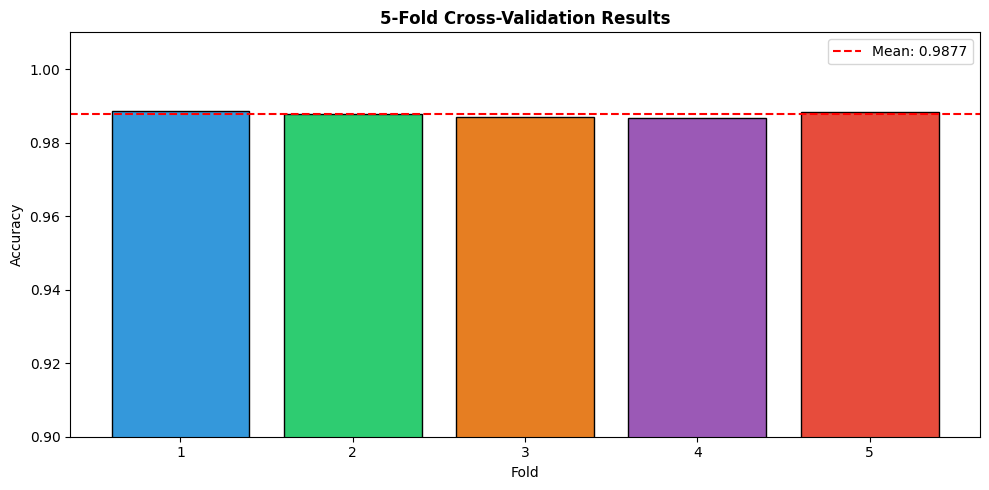

In [18]:
# Cross-Validation Analysis
print("=" * 60)
print("CROSS-VALIDATION ANALYSIS")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42),
    X_combined_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1
)

print(f"5-Fold Cross-Validation Results:")
print(f"  Mean Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
print(f"  Individual Folds: {[f'{s:.4f}' for s in cv_scores]}")

# Visualize CV results
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 6), cv_scores, color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c'],
       edgecolor='black')
ax.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold Cross-Validation Results', fontweight='bold')
ax.set_xticks(range(1, 6))
ax.legend()
ax.set_ylim(0.9, 1.01)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

FEATURE IMPORTANCE ANALYSIS


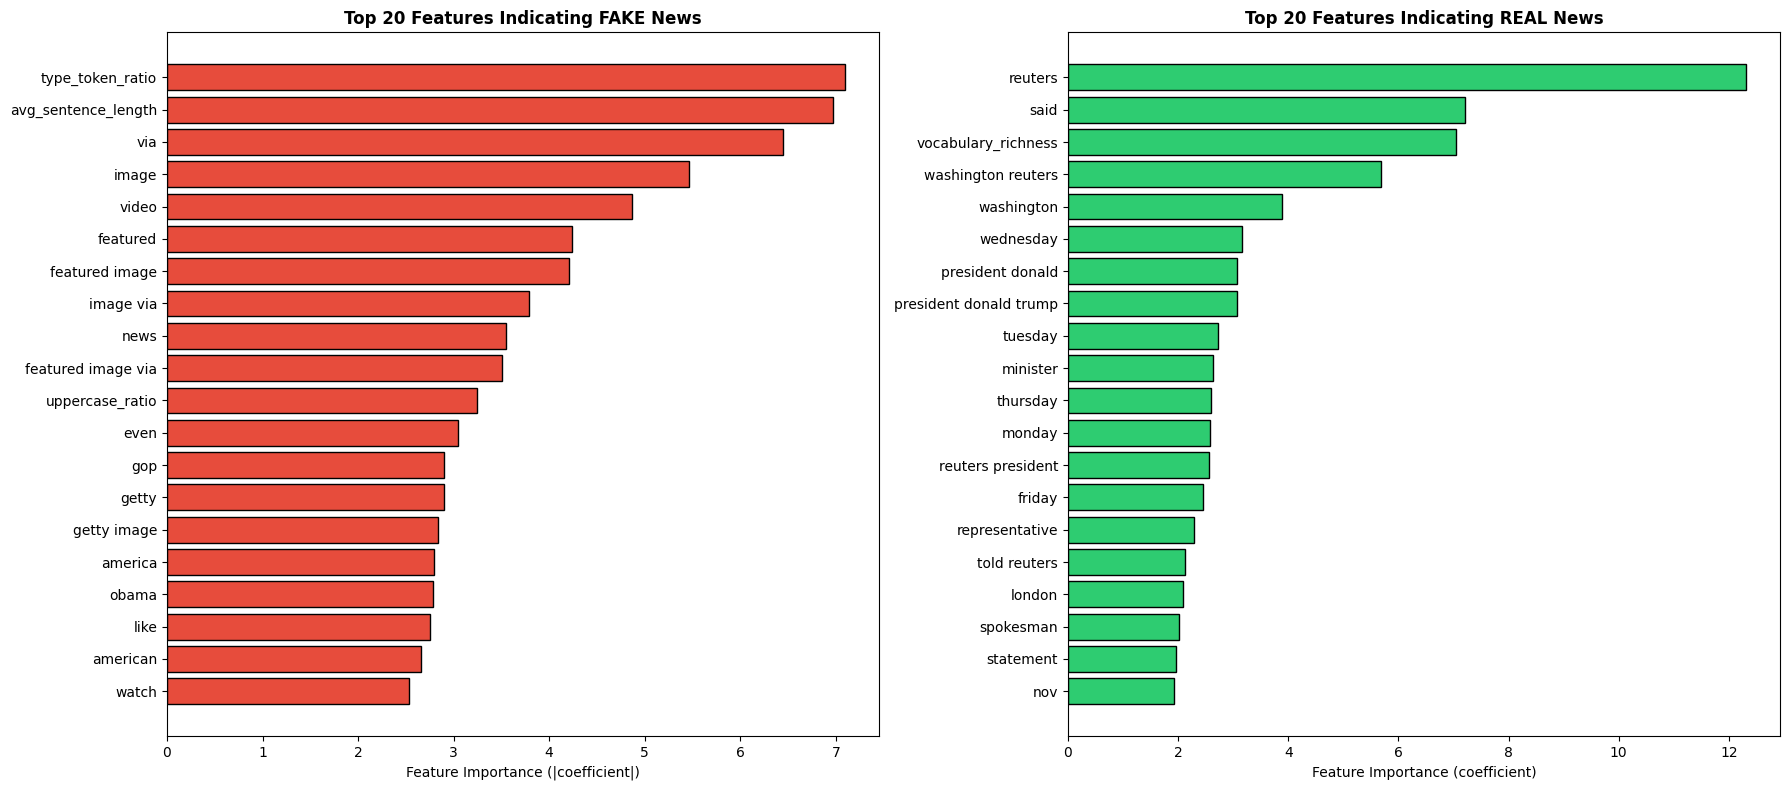


Linguistic Feature Importance:
  type_token_ratio              : -7.0976 → FAKE
  vocabulary_richness           : +7.0433 → REAL
  avg_sentence_length           : -6.9668 → FAKE
  uppercase_ratio               : -3.2485 → FAKE
  word_count                    : -2.1314 → FAKE
  stopword_ratio                : -1.4697 → FAKE
  sentence_count                : +1.2316 → REAL
  avg_word_length               : -0.8925 → FAKE
  quote_count                   : +0.7915 → REAL
  long_word_ratio               : +0.6966 → REAL
  char_count                    : +0.5998 → REAL
  punctuation_ratio             : +0.5579 → REAL
  digit_ratio                   : -0.4915 → FAKE
  sentiment_subjectivity        : -0.4308 → FAKE
  question_count                : -0.4122 → FAKE
  exclamation_count             : -0.4021 → FAKE
  paragraph_count               : +0.3875 → REAL
  capital_word_count            : +0.3611 → REAL
  ellipsis_count                : +0.3542 → REAL
  sensational_word_count        : -0.

In [19]:
# Feature Importance Analysis
print("=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Get feature names
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
linguistic_feature_names = linguistic_df.columns.tolist()
all_feature_names = list(tfidf_feature_names) + linguistic_feature_names

# Get coefficients from logistic regression
coefficients = final_model.coef_[0]

# Top features for detecting FAKE news (negative coefficients)
fake_indices = np.argsort(coefficients)[:20]
fake_features = [(all_feature_names[i], coefficients[i]) for i in fake_indices]

# Top features for detecting REAL news (positive coefficients)
real_indices = np.argsort(coefficients)[-20:][::-1]
real_features = [(all_feature_names[i], coefficients[i]) for i in real_indices]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Fake news indicators
fake_names = [f[0][:30] for f in fake_features]
fake_vals = [abs(f[1]) for f in fake_features]
axes[0].barh(range(len(fake_names)), fake_vals, color='#e74c3c', edgecolor='black')
axes[0].set_yticks(range(len(fake_names)))
axes[0].set_yticklabels(fake_names)
axes[0].set_title('Top 20 Features Indicating FAKE News', fontweight='bold')
axes[0].set_xlabel('Feature Importance (|coefficient|)')
axes[0].invert_yaxis()

# Real news indicators
real_names = [f[0][:30] for f in real_features]
real_vals = [f[1] for f in real_features]
axes[1].barh(range(len(real_names)), real_vals, color='#2ecc71', edgecolor='black')
axes[1].set_yticks(range(len(real_names)))
axes[1].set_yticklabels(real_names)
axes[1].set_title('Top 20 Features Indicating REAL News', fontweight='bold')
axes[1].set_xlabel('Feature Importance (coefficient)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Show linguistic feature importance specifically
print("\nLinguistic Feature Importance:")
ling_start = len(tfidf_feature_names)
ling_coeffs = coefficients[ling_start:]
ling_importance = list(zip(linguistic_feature_names, ling_coeffs))
ling_importance.sort(key=lambda x: abs(x[1]), reverse=True)

for name, coef in ling_importance:
    direction = "→ REAL" if coef > 0 else "→ FAKE"
    print(f"  {name:30s}: {coef:+.4f} {direction}")

In [20]:
# Summary and Project Documentation
print("=" * 80)
print("  FAKE NEWS DETECTOR FOR STUDENTS - PROJECT SUMMARY")
print("=" * 80)

print(f"""
📊 DATASET:
   - Source: Kaggle (Real and Fake News Dataset)
   - Total Articles: {len(df):,}
   - Real Articles: {len(df[df['label']==1]):,}
   - Fake Articles: {len(df[df['label']==0]):,}

🔧 FEATURES:
   - TF-IDF Features: {len(tfidf_vectorizer.get_feature_names_out()):,} (unigrams, bigrams, trigrams)
   - Linguistic Features: {len(linguistic_df.columns)} handcrafted features
     Including: sentiment, subjectivity, sensationalism score, vocabulary richness,
     punctuation patterns, writing quality indicators

🤖 MODEL PERFORMANCE:
   - Algorithm: Logistic Regression (with combined features)
   - Test Accuracy: {accuracy_score(y_test, y_pred_final)*100:.2f}%
   - F1 Score: {f1_score(y_test, y_pred_final, average='weighted'):.4f}
   - ROC-AUC: {roc_auc_score(y_test, y_prob_final[:, 1]):.4f}
   - Cross-Validation: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*200:.2f}%)

📋 SYSTEM COMPONENTS:
   1. ✅ Text-based feature extraction (TF-IDF + linguistic cues)
   2. ✅ ML Classifier (Logistic Regression with combined features)
   3. ✅ Heuristic Credibility Scoring (rule-based complement)
   4. ✅ Article Summarization (Transformer-based / Extractive fallback)
   5. ✅ Student-friendly explanations and tips
   6. ✅ Interactive Streamlit web application (app.py)

📁 SAVED ARTIFACTS:
   - models/fake_news_model.joblib
   - models/tfidf_vectorizer.joblib
   - models/feature_scaler.joblib
   - models/preprocessor.pkl
   - models/scorer.pkl
   - models/feature_info.pkl
""")



  FAKE NEWS DETECTOR FOR STUDENTS - PROJECT SUMMARY

📊 DATASET:
   - Source: Kaggle (Real and Fake News Dataset)
   - Total Articles: 45,757
   - Real Articles: 22,900
   - Fake Articles: 22,857

🔧 FEATURES:
   - TF-IDF Features: 50,000 (unigrams, bigrams, trigrams)
   - Linguistic Features: 21 handcrafted features
     Including: sentiment, subjectivity, sensationalism score, vocabulary richness,
     punctuation patterns, writing quality indicators

🤖 MODEL PERFORMANCE:
   - Algorithm: Logistic Regression (with combined features)
   - Test Accuracy: 99.08%
   - F1 Score: 0.9908
   - ROC-AUC: 0.9986
   - Cross-Validation: 98.77% (+/- 0.16%)

📋 SYSTEM COMPONENTS:
   1. ✅ Text-based feature extraction (TF-IDF + linguistic cues)
   2. ✅ ML Classifier (Logistic Regression with combined features)
   3. ✅ Heuristic Credibility Scoring (rule-based complement)
   4. ✅ Article Summarization (Transformer-based / Extractive fallback)
   5. ✅ Student-friendly explanations and tips
   6. ✅ Interac